Epoch 1/50
7/7 [==============================] - 3s 5ms/step - loss: 0.2851
Epoch 2/50
7/7 [==============================] - 0s 6ms/step - loss: 0.2583
Epoch 3/50
7/7 [==============================] - 0s 4ms/step - loss: 0.2513
Epoch 4/50
7/7 [==============================] - 0s 4ms/step - loss: 0.2387
Epoch 5/50
7/7 [==============================] - 0s 4ms/step - loss: 0.2224
Epoch 6/50
7/7 [==============================] - 0s 6ms/step - loss: 0.2194
Epoch 7/50
7/7 [==============================] - 0s 5ms/step - loss: 0.2003
Epoch 8/50
7/7 [==============================] - 0s 6ms/step - loss: 0.1963
Epoch 9/50
7/7 [==============================] - 0s 4ms/step - loss: 0.1829
Epoch 10/50
7/7 [==============================] - 0s 4ms/step - loss: 0.1900
Epoch 11/50
7/7 [==============================] - 0s 4ms/step - loss: 0.1593
Epoch 12/50
7/7 [==============================] - 0s 4ms/step - loss: 0.1572
Epoch 13/50
7/7 [==============================] - 0s 4ms/step - loss: 0.

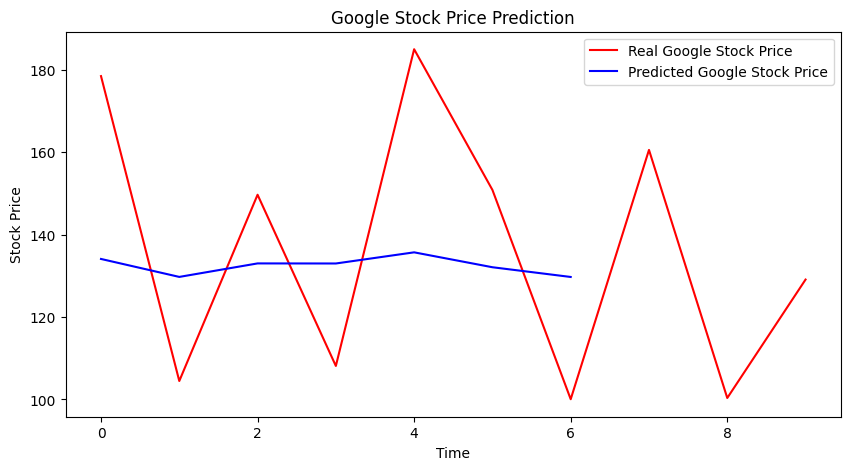

In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, LSTM, Dropout

# Load Google stock price dataset
dataset_train = pd.read_csv(r"C:\Users\Yash Sud\OneDrive\Desktop\Google_Stock_Price_Train.csv")
training_set = dataset_train.iloc[:, 1:2].values  # Use "Open" price column

# Feature Scaling
scaler = MinMaxScaler(feature_range=(0, 1))
training_set_scaled = scaler.fit_transform(training_set)

# Creating a data structure with 3 time-steps and 1 output
X_train, y_train = [], []
for i in range(3, len(training_set)):
    X_train.append(training_set_scaled[i-3:i, 0])
    y_train.append(training_set_scaled[i, 0])

X_train, y_train = np.array(X_train), np.array(y_train)

# Reshaping for LSTM input
X_train = np.reshape(X_train, (X_train.shape[0], X_train.shape[1], 1))

# Building the LSTM model
model = Sequential()
model.add(LSTM(units=10, return_sequences=True, input_shape=(X_train.shape[1], 1)))
model.add(Dropout(0.2))
model.add(LSTM(units=10, return_sequences=False))
model.add(Dropout(0.2))
model.add(Dense(units=1))  # Output layer

# Compiling the model
model.compile(optimizer='adam', loss='mean_squared_error')

# Training the model
model.fit(X_train, y_train, epochs=50, batch_size=1)

# Making predictions
predicted_stock_price = model.predict(X_train)
predicted_stock_price = scaler.inverse_transform(predicted_stock_price)

# Visualizing the results
plt.figure(figsize=(10, 5))
plt.plot(training_set, color='red', label='Real Google Stock Price')
plt.plot(predicted_stock_price, color='blue', label='Predicted Google Stock Price')
plt.title('Google Stock Price Prediction')
plt.xlabel('Time')
plt.ylabel('Stock Price')
plt.legend()
plt.show()